### template match

In [50]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('07_opencv/img/cards.png', cv.IMREAD_GRAYSCALE)
tmp_img = cv.imread('07_opencv/img/poker.png', cv.IMREAD_GRAYSCALE)

(130, 87)
(130, 87)
(array([75, 76, 77]), array([171, 171, 171]))


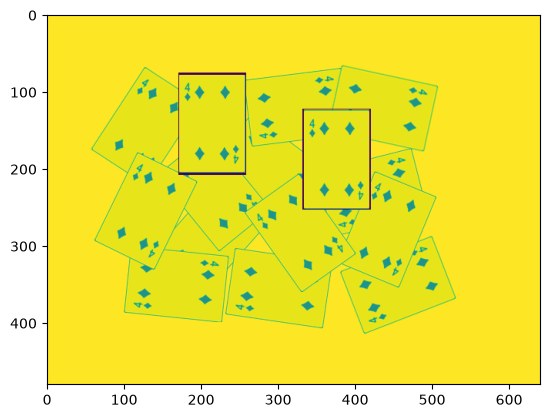

In [60]:
rl_roi = img[120:250, 333:420]
tmp_resize = cv.resize(tmp_img, (rl_roi.shape[1], rl_roi.shape[0]))

print(tmp_resize.shape)
print(rl_roi.shape)

rw, rh = tmp_resize.shape[::-1]
r_ret = cv.matchTemplate(img, tmp_resize, cv.TM_CCOEFF_NORMED)
r_loc = np.where(r_ret > 0.8)

# min_val, max_val, min_loc, max_loc = cv.minMaxLoc(r_ret)
# cv.rectangle(img, max_loc, (max_loc[0] + rw, max_loc[1] + rh), (0, 255, 0), 0)
print(r_loc)

for pt in zip(*r_loc[::-1]):
    cv.rectangle(img, pt, (pt[0] + rw, pt[1] + rh), (0, 255, 0))

plt.imshow(img)


In [52]:
# plt.imshow(r_ret, cmap='gray')

In [82]:
# rotated template match 

def rotate_img(img, angle):
    h, w = img.shape[:2]
    # 原图中心
    cx, cy = w / 2, h / 2
    # 旋转矩阵
    M = cv.getRotationMatrix2D((cx, cy), angle, 1.0)
    # 取旋转矩阵中的 cos、sin
    cos = abs(M[0, 0])
    sin = abs(M[0, 1])
    # 计算旋转后的新画布大小
    new_w = int(h * sin + w * cos)
    new_h = int(h * cos + w * sin)
    # 修正平移量，让旋转后的图像位于新画布中心
    M[0, 2] += new_w / 2 - cx
    M[1, 2] += new_h / 2 - cy
    return cv.warpAffine(img, M, (new_w, new_h))

def match(img, t_img, score):
    h, w = t_img.shape[:2]
    ret = cv.matchTemplate(img, t_img, cv.TM_CCOEFF_NORMED)
    loc = np.where(ret > score)
    
    for pt in zip(*loc[::-1]):
        for pt in zip(*loc[::-1]):
            cv.rectangle(img, pt, (pt[0] + w, pt[1] + h), (0, 255, 0))
    return None

# tt_img = rotate_img(tmp_resize, 160)
# plt.imshow(tt_img)

scr = 0.4
agl = [a for a in range(0,180)]

for a in agl:
    r_img = rotate_img(tmp_resize, a)
    ret = match(img, r_img, scr)
plt.imshow(img, cmap='gray')
        


KeyboardInterrupt: 